# Temporal Order Experiment: LSTM on Ordered vs Shuffled Intrahour Data

**Author:** Ayooluwa Adelagun  
**Dataset:** NVDA Intrahour Volatility Dataset  

---

## Purpose

This notebook implements the temporal order experiment described in **Section 5.1** of the dissertation.

The central question is whether the sequential structure of the intrahour dataset carries genuine predictive information, or whether the LSTM is simply learning from the marginal distribution of feature values regardless of their order.

Two identical LSTM models are trained:

- **Model A (Shuffled):** trained on a randomly shuffled version of the full dataset, destroying all temporal ordering.
- **Model B (Ordered):** trained on the dataset in its natural chronological sequence.

If temporal order carries no information, both models should converge to the same training accuracy. A persistent gap (with the ordered model learning and the shuffled model flatlining) confirms that the LSTM is exploiting genuine sequential structure, validating the use of recurrent architectures for both the intrahour and intraday forecasting tasks.

## 1. Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM, Input, Activation
from tensorflow.keras.models import Model
from sklearn.preprocessing import MinMaxScaler

## 2. Load Data

The full intrahour dataset is loaded. A shuffled copy is created immediately using a fixed `random_state=42` to ensure reproducibility. The original (ordered) dataframe is left unchanged.

In [20]:
data_full = pd.read_csv('NVDA_Intrahour_Volatility_Dataset.csv')
shuffled_data_full = data_full.sample(frac=1, random_state=42)

## 3. Train-Test Split

Both datasets are split at the 80% mark. For the ordered dataset this preserves temporal integrity. For the shuffled dataset the split is arbitrary by design. The experiment is concerned with the effect of destroying temporal structure, not with out-of-sample generalisation.

> **Note:** `training_features_a` and `training_features_b` refer to the shuffled and ordered training sets respectively.

In [21]:
# Chronological 80/20 split
splitlimit = int(len(data_full) * 0.8)
training_features_a, test_data_a = shuffled_data_full[:splitlimit], shuffled_data_full[splitlimit:]
training_features_b, test_data_b = data_full[:splitlimit], data_full[splitlimit:]

## 4. Feature and Target Arrays

Feature matrices `X` and target vectors `Y` are extracted for both datasets. The full datasets are also retained as `data_set_a/b` for use in the scaling step.

In [22]:
X_a = shuffled_data_full[["Return_Squared", "Hourly Volatility"]]
Y_a = shuffled_data_full["target"]
data_set_a = shuffled_data_full[["Return_Squared", "Hourly Volatility", "target"]]

X_b = data_full[["Return_Squared", "Hourly Volatility"]]
Y_b = data_full["target"]
data_set_b = data_full[["Return_Squared", "Hourly Volatility", "target"]]

## 5. Outlier Removal

Outliers are removed from the **training set only**, using a rolling median absolute deviation (MAD) approach with a centred window of 41 observations. An observation is flagged and removed if its absolute deviation from the rolling median exceeds 2x the global MAD of deviations across the training set.

This procedure is applied sequentially to `Hourly Volatility` and `Return Squared`; any row flagged on either feature is removed. The procedure mirrors Section 3.7 of the dissertation and is identical for both the shuffled and ordered training sets.

In [23]:
# Outlier detection on training data — 2x MAD

training_features_a["hourly_volatility_rolling_median"] = training_features_a["Hourly Volatility"].rolling(window=41, center=True, min_periods=1).median()
training_features_a["return_squared_rolling_median"] = training_features_a["Return_Squared"].rolling(window=41, center=True, min_periods=1).median()
training_features_a["volatility minus median"] = (training_features_a["Hourly Volatility"] - training_features_a["hourly_volatility_rolling_median"]).abs()
training_features_a["return minus median"] = (training_features_a["Return_Squared"] - training_features_a["return_squared_rolling_median"]).abs()
volatility_outliers_removed_a = training_features_a[~(training_features_a['volatility minus median'] > 2 * training_features_a['volatility minus median'].median())]
both_outliers_removed_a = volatility_outliers_removed_a[~(volatility_outliers_removed_a['return minus median'] > 2 * volatility_outliers_removed_a['return minus median'].median())]

removed_a = len(training_features_a) - len(both_outliers_removed_a)

training_features_b["hourly_volatility_rolling_median"] = training_features_b["Hourly Volatility"].rolling(window=41, center=True, min_periods=1).median()
training_features_b["return_squared_rolling_median"] = training_features_b["Return_Squared"].rolling(window=41, center=True, min_periods=1).median()
training_features_b["volatility minus median"] = (training_features_b["Hourly Volatility"] - training_features_b["hourly_volatility_rolling_median"]).abs()
training_features_b["return minus median"] = (training_features_b["Return_Squared"] - training_features_b["return_squared_rolling_median"]).abs()
volatility_outliers_removed_b = training_features_b[~(training_features_b['volatility minus median'] > 2 * training_features_b['volatility minus median'].median())]
both_outliers_removed_b = volatility_outliers_removed_b[~(volatility_outliers_removed_b['return minus median'] > 2 * volatility_outliers_removed_b['return minus median'].median())]

removed_b = len(training_features_b) - len(both_outliers_removed_b)

/var/folders/1q/12m2t3kx34d184nxq9fqf_100000gp/T/ipykernel_30033/4234913988.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_features_a["hourly_volatility_rolling_median"] = training_features_a["Hourly Volatility"].rolling(window=41, center=True, min_periods=1).median()
/var/folders/1q/12m2t3kx34d184nxq9fqf_100000gp/T/ipykernel_30033/4234913988.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_features_a["return_squared_rolling_median"] = training_features_a["Return_Squared"].rolling(

## 6. Cleaned Feature and Target Arrays

Feature matrices and target vectors are re-extracted from the cleaned training sets for use in the scaling and sequence construction steps that follow.

In [24]:
X_cleaned_a = both_outliers_removed_a[["Return_Squared", "Hourly Volatility"]]
Y_cleaned_a = both_outliers_removed_a["target"]
data_set_cleaned_a = both_outliers_removed_a[["Return_Squared", "Hourly Volatility", "target"]]

X_cleaned_b = both_outliers_removed_b[["Return_Squared", "Hourly Volatility"]]
Y_cleaned_b = both_outliers_removed_b["target"]
data_set_cleaned_b = both_outliers_removed_b[["Return_Squared", "Hourly Volatility", "target"]]

## 7. Feature Scaling

Min-max scaling is applied to the feature columns only. Each scaler is fitted exclusively on its respective cleaned training set. Fitting the scaler on training data only ensures no look-ahead bias is introduced.

In [ ]:
# Scale features only. Scaler fitted once per dataset.
scaler_a = MinMaxScaler()
training_data_features_scaled_a = scaler_a.fit_transform(X_cleaned_a)
data_set_scaled_a = np.column_stack([
    training_data_features_scaled_a,
    data_set_cleaned_a["target"].values
])

scaler_b = MinMaxScaler()
training_data_features_scaled_b = scaler_b.fit_transform(X_cleaned_b)
data_set_scaled_b = np.column_stack([
    training_data_features_scaled_b,
    data_set_cleaned_b["target"].values
])

## 8. Sequence Construction

Input sequences of length `backcandles = 15` are constructed from the scaled feature arrays. Each sequence $\mathbf{x}_{t-L+1:t} \in \mathbb{R}^{L \times p}$ is paired with the target label at time $t+1$.

The sequence length of 15 is motivated by the ACF and CCF analysis in Chapter 5, which confirms statistically significant temporal dependence in both `Hourly Volatility` and `Return Squared` out to at least lag 15.

For the shuffled dataset, consecutive observations within each sequence are temporally arbitrary. This is the key manipulation that destroys sequential structure while preserving the marginal feature distributions.

In [26]:
# Sequence construction — 15 backcandles
backcandles = 15

Z_a = []
for j in range(2):
    Z_a.append([])
    for i in range(backcandles, training_data_features_scaled_a.shape[0]):
        Z_a[j].append(training_data_features_scaled_a[i-backcandles:i, j])
Z_a = np.moveaxis(Z_a, [0], [2])
Z_a = np.array(Z_a)
yi_a = np.array(data_set_scaled_a[backcandles-1:, -1])
y_final_a = np.reshape(yi_a, (len(yi_a), 1))[1:]

Z_b = []
for j in range(2):
    Z_b.append([])
    for i in range(backcandles, training_data_features_scaled_b.shape[0]):
        Z_b[j].append(training_data_features_scaled_b[i-backcandles:i, j])
Z_b = np.moveaxis(Z_b, [0], [2])
Z_b = np.array(Z_b)
yi_b = np.array(data_set_scaled_b[backcandles-1:, -1])
y_final_b = np.reshape(yi_b, (len(yi_b), 1))[1:]

## 9. Model A: LSTM on Shuffled Data

The LSTM is trained on shuffled sequences. With no genuine temporal structure in the input, the model is expected to learn only from the marginal distribution of feature values and converge quickly to a flat accuracy near the base rate of the dataset.

In [27]:
# LSTM on shuffled data
lstm_input_a = Input(shape=(backcandles, 2), name='lstm_input')
inputs_a = LSTM(80, name='first_layer')(lstm_input_a)
inputs_a = Dense(1, name='dense_layer')(inputs_a)
output_a = Activation('sigmoid', name='output')(inputs_a)

model_a = Model(inputs=lstm_input_a, outputs=output_a)
model_a.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_a = model_a.fit(x=Z_a, y=y_final_a, epochs=30, validation_data=(Z_a, y_final_a))

Epoch 1/30
999/999 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6406 - loss: 0.6547 - val_accuracy: 0.6407 - val_loss: 0.6535
Epoch 2/30
999/999 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6407 - loss: 0.6536 - val_accuracy: 0.6407 - val_loss: 0.6535
Epoch 3/30
999/999 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6407 - loss: 0.6534 - val_accuracy: 0.6407 - val_loss: 0.6534
Epoch 4/30
999/999 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6407 - loss: 0.6533 - val_accuracy: 0.6407 - val_loss: 0.6533
Epoch 5/30
999/999 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6407 - loss: 0.6532 - val_accuracy: 0.6407 - val_loss: 0.6532
Epoch 6/30
999/999 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6407 - loss: 0.6531 - val_accuracy: 0.6407 - val_loss: 0.6531
Epoch 7/30
999/999 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6407 - loss: 0.6531 - val_accuracy: 0.6407 - val_loss: 0.6531
Epoch 8/30
999/999 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6407 - loss: 0.6531 - val_accuracy: 0.

## 10. Model B: LSTM on Ordered Data

The identical architecture is trained on sequences in their natural chronological order. If temporal structure is genuinely informative, this model should improve steadily across epochs, pulling away from the shuffled model's accuracy.

In [28]:
# LSTM on ordered data
lstm_input_b = Input(shape=(backcandles, 2), name='lstm_input')
inputs_b = LSTM(80, name='first_layer')(lstm_input_b)
inputs_b = Dense(1, name='dense_layer')(inputs_b)
output_b = Activation('sigmoid', name='output')(inputs_b)

model_b = Model(inputs=lstm_input_b, outputs=output_b)
model_b.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_b = model_b.fit(x=Z_b, y=y_final_b, epochs=30, validation_data=(Z_b, y_final_b))

Epoch 1/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6322 - loss: 0.6564 - val_accuracy: 0.6327 - val_loss: 0.6482
Epoch 2/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6371 - loss: 0.6355 - val_accuracy: 0.6488 - val_loss: 0.6219
Epoch 3/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6521 - loss: 0.6185 - val_accuracy: 0.6590 - val_loss: 0.6122
Epoch 4/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6575 - loss: 0.6120 - val_accuracy: 0.6608 - val_loss: 0.6087
Epoch 5/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6586 - loss: 0.6091 - val_accuracy: 0.6615 - val_loss: 0.6069
Epoch 6/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6604 - loss: 0.6075 - val_accuracy: 0.6622 - val_loss: 0.6059
Epoch 7/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6613 - loss: 0.6065 - val_accuracy: 0.6633 - val_loss: 0.6053
Epoch 8/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6619 - loss: 0.6058 - val_accuracy: 0.

## 11. Results: Training Accuracy Curves

The plot below reproduces **Figure 5.1** from the dissertation. A persistent gap between the two curves (with the ordered model improving and the shuffled model flatlining) is the key result confirming that the LSTM exploits temporal order rather than simply memorising feature value distributions.

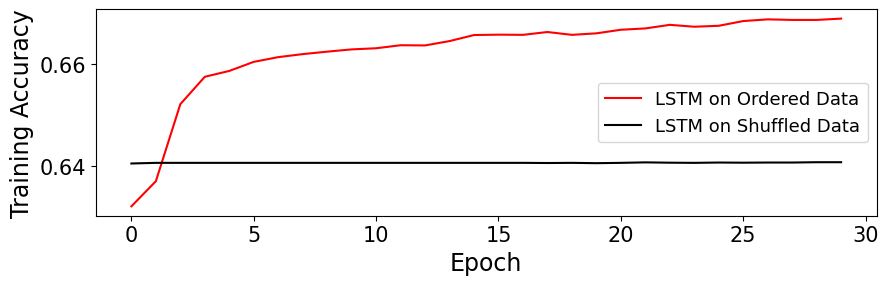

In [29]:
plt.figure(figsize=(9, 3))

plt.plot(history_b.history['accuracy'], color='red', label='LSTM on Ordered Data')
plt.plot(history_a.history['accuracy'], color='black', label='LSTM on Shuffled Data')

plt.gca().tick_params(axis='x', labelsize=15)
plt.gca().tick_params(axis='y', labelsize=15)
plt.xlabel('Epoch', size=17)
plt.ylabel('Training Accuracy', size=17)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig('NVDA_Intrahour_LSTM_Ordered_vs_Shuffled.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()